<a href="https://colab.research.google.com/github/Fatima-Tuj-Johara/Fatima-Tuj-Johara/blob/main/Google_Play_Store_Analysis_Python/Google_Play_Store_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
# Importing the important Python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub


sns.set_theme(style="darkgrid", palette="muted")


path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps


In [198]:
base_path = "/kaggle/input/google-play-store-apps"

csv_file_path = os.path.join(base_path, "googleplaystore.csv")

df_store = pd.read_csv(csv_file_path, encoding='latin-1')

print(df_store.shape)
df_store.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [199]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [200]:
df_store.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10836,False
10837,False
10838,False
10839,False


In [201]:
# Handling Missing Values
df_store.dropna(inplace=True)

# Dealing with Duplicates
df_store.drop_duplicates(inplace=True)


In [202]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8886 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8886 non-null   object 
 1   Category        8886 non-null   object 
 2   Rating          8886 non-null   float64
 3   Reviews         8886 non-null   object 
 4   Size            8886 non-null   object 
 5   Installs        8886 non-null   object 
 6   Type            8886 non-null   object 
 7   Price           8886 non-null   object 
 8   Content Rating  8886 non-null   object 
 9   Genres          8886 non-null   object 
 10  Last Updated    8886 non-null   object 
 11  Current Ver     8886 non-null   object 
 12  Android Ver     8886 non-null   object 
dtypes: float64(1), object(12)
memory usage: 971.9+ KB


In [203]:
df_store.duplicated().sum()

np.int64(0)

In [204]:
# Removing Outliers
z_scores = np.abs((df_store['Rating'] - df_store['Rating'].mean()) / df_store['Rating'].std())
df_store = df_store[z_scores < 3]  # Keep rows within 3 standard deviations

In [205]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8714 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8714 non-null   object 
 1   Category        8714 non-null   object 
 2   Rating          8714 non-null   float64
 3   Reviews         8714 non-null   object 
 4   Size            8714 non-null   object 
 5   Installs        8714 non-null   object 
 6   Type            8714 non-null   object 
 7   Price           8714 non-null   object 
 8   Content Rating  8714 non-null   object 
 9   Genres          8714 non-null   object 
 10  Last Updated    8714 non-null   object 
 11  Current Ver     8714 non-null   object 
 12  Android Ver     8714 non-null   object 
dtypes: float64(1), object(12)
memory usage: 953.1+ KB


In [206]:
# Change the data type of Installs column to numrical data type and remove the commma and the plus symbols:
df_store['Installs'] = df_store['Installs'].str.replace('+', '')
df_store['Installs'] = df_store['Installs'].str.replace(',', '')
df_store['Installs'] = df_store['Installs'].astype(int)

# Change the data type of Reviews column to numrical data type:
df_store['Reviews'] = df_store['Reviews'].astype(int)

In [207]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8714 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8714 non-null   object 
 1   Category        8714 non-null   object 
 2   Rating          8714 non-null   float64
 3   Reviews         8714 non-null   int64  
 4   Size            8714 non-null   object 
 5   Installs        8714 non-null   int64  
 6   Type            8714 non-null   object 
 7   Price           8714 non-null   object 
 8   Content Rating  8714 non-null   object 
 9   Genres          8714 non-null   object 
 10  Last Updated    8714 non-null   object 
 11  Current Ver     8714 non-null   object 
 12  Android Ver     8714 non-null   object 
dtypes: float64(1), int64(2), object(10)
memory usage: 953.1+ KB


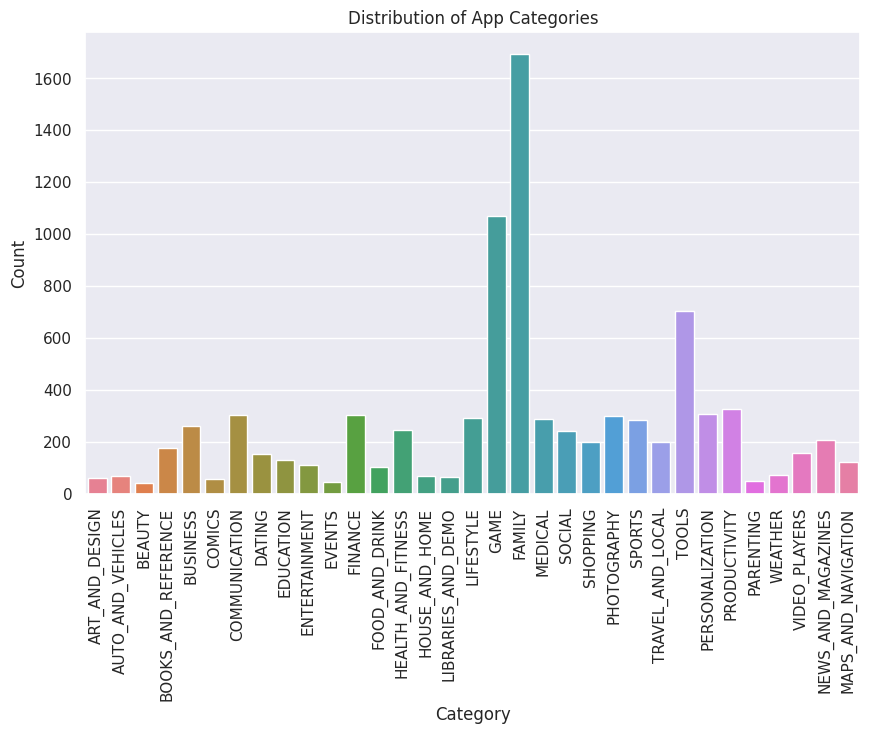

In [208]:
# Bar Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_store, x='Category',hue='Category',legend=False)
plt.xlabel('Category')
plt.xticks( rotation=90)
plt.ylabel('Count')
plt.title('Distribution of App Categories')
plt.show()

Insights from the Visual:

Top Performers: FAMILY and GAME apps completely dominate the Google Play Store with the highest count.

Niche Markets: Categories like BEAUTY and EVENTS are the rarest, with very few apps.


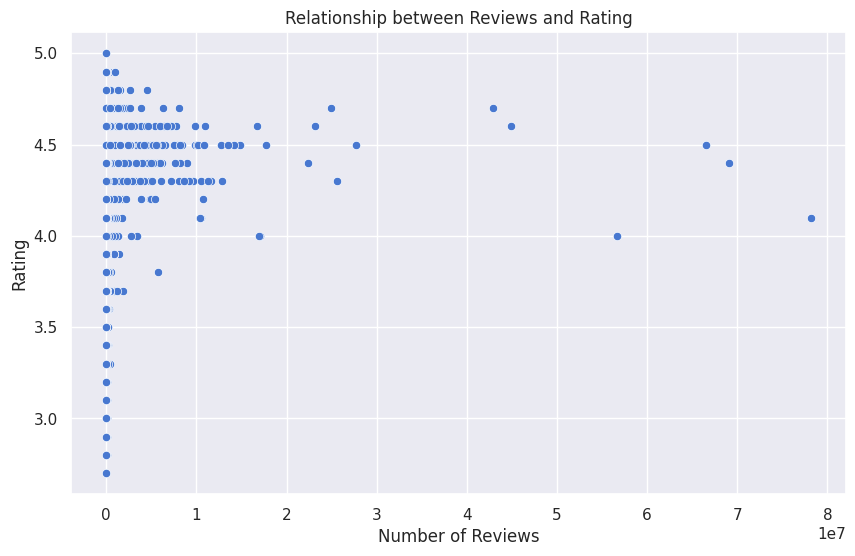

<Figure size 640x480 with 0 Axes>

In [209]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_store, x='Reviews', y='Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.title('Relationship between Reviews and Rating')
plt.show()
plt.tight_layout()

Apps with fewer reviews have highly unpredictable ratings, ranging from very low to perfect.

Apps with millions of reviews stay consistently strong, holding stable ratings between 4.0 and 4.7.

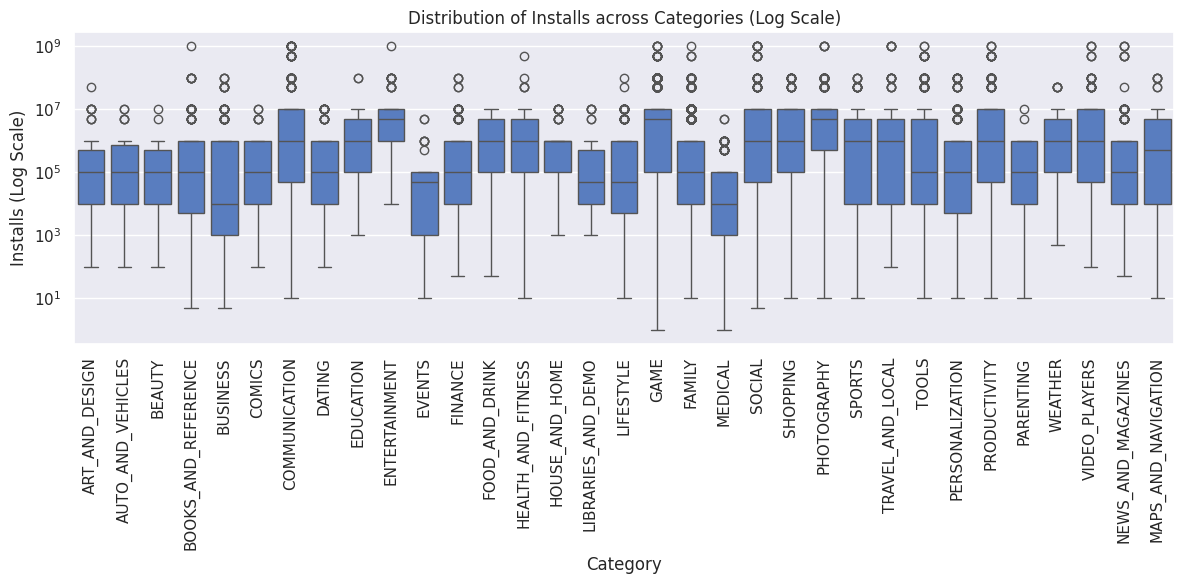

In [210]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_store, x='Category', y='Installs')

plt.yscale('log')

plt.xticks(rotation=90)
plt.title('Distribution of Installs across Categories (Log Scale)')
plt.ylabel('Installs (Log Scale)')
plt.tight_layout()
plt.show()

GAME, COMMUNICATION, and ENTERTAINMENT show the highest average performance, with their median download boxes sitting much higher up the scale ($10^6$ to $10^7$).Categories like MEDICAL and EVENTS lag behind, showing significantly lower median install counts.

In [211]:
from scipy.stats import ttest_ind

# Splitting the dataset into free and paid apps
free_apps = df_store[df_store['Type'] == 'Free']
paid_apps = df_store[df_store['Type'] == 'Paid']

In [212]:
# Performing t-test
t_stat, p_value = ttest_ind(free_apps['Rating'], paid_apps['Rating'])

In [213]:
p_value

np.float64(6.283203579258039e-06)

In [214]:
# Checking the p-value
if p_value < 0.05:
    print("Reject null hypothesis: There is a significant difference in ratings.")
else:
    print("Fail to reject null hypothesis: There is no significant difference in ratings.")

Reject null hypothesis: There is a significant difference in ratings.


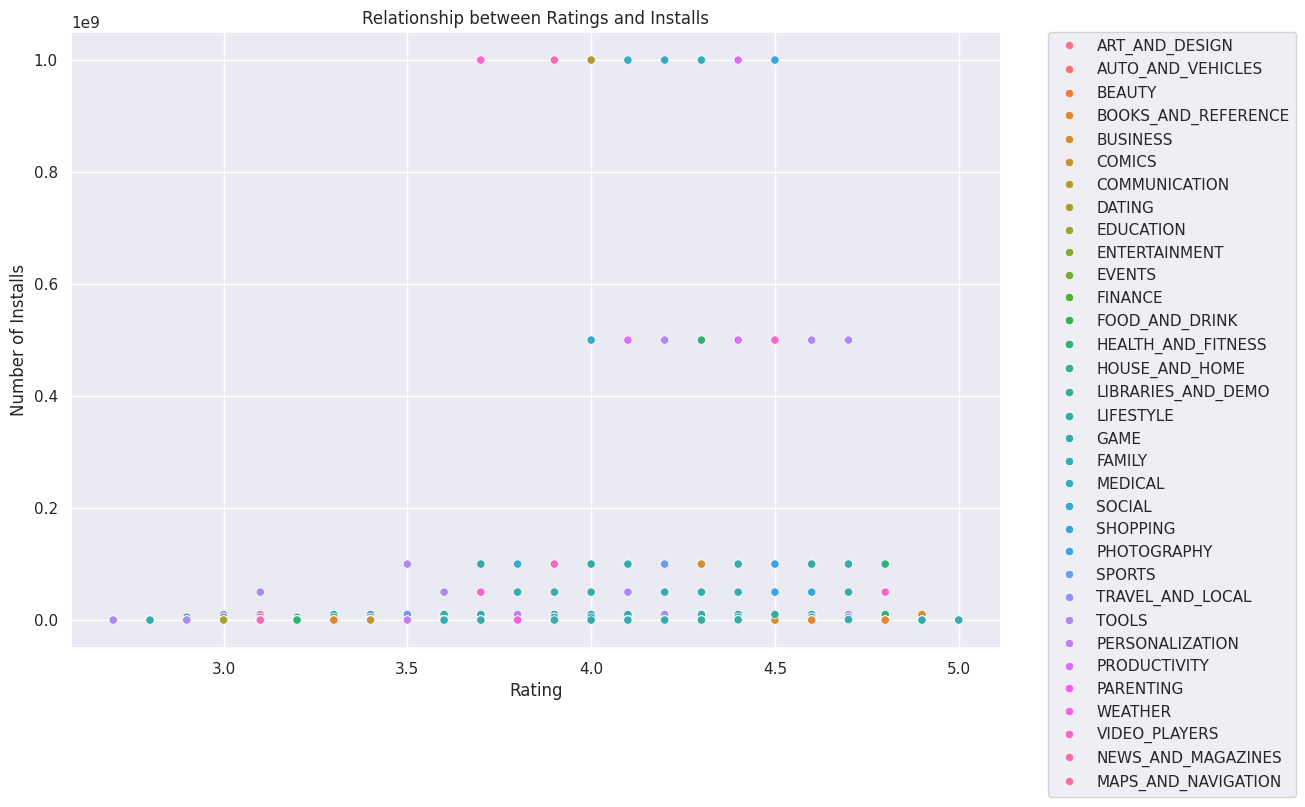

In [215]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_store, x='Rating', y='Installs', hue='Category')
plt.grid(True)
plt.xlabel('Rating')
plt.ylabel('Number of Installs')
plt.title('Relationship between Ratings and Installs')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

Text(0.5, 1.0, 'Average Rating Trend over Time')

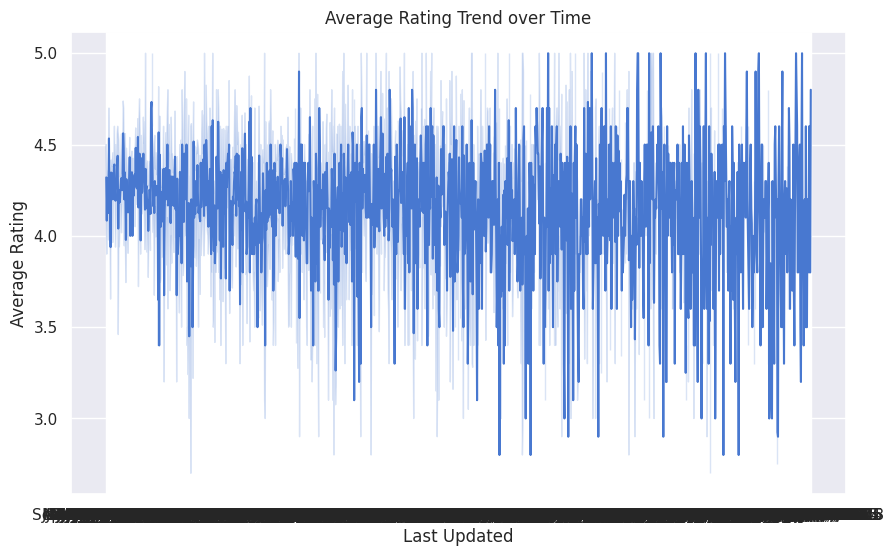

In [216]:
# Line plot of Average Rating over Time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_store, x='Last Updated', y='Rating')
plt.xlabel('Last Updated')
plt.ylabel('Average Rating')
plt.title('Average Rating Trend over Time')

In [217]:
df_store.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [218]:
# Convert 'Last Updated' to datetime
df_store['Last Updated'] = pd.to_datetime(df_store['Last Updated'])

# Set 'Last Updated' as the index
df_store.set_index('Last Updated', inplace=True)

# Resample 'Rating' to monthly frequency
df_store_monthly = df_store['Rating'].resample('M').mean()

/tmp/ipykernel_2609/1170281224.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_store_monthly = df_store['Rating'].resample('M').mean()


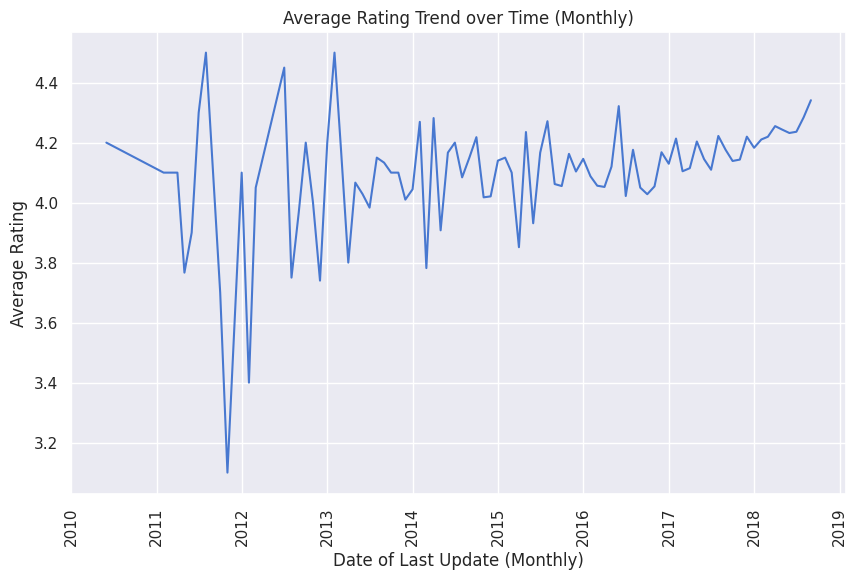

In [219]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_store_monthly)
plt.xlabel('Date of Last Update (Monthly)')
plt.xticks(rotation=90)
plt.ylabel('Average Rating')
plt.title('Average Rating Trend over Time (Monthly)')
plt.show()

Conclusion:

To wrap things up, the biggest takeaway here is that launching a successful app shouldn't be based on guesswork. The data clearly shows that your app's success comes down to a few smart choices: picking the right category, finding that pricing sweet spot, and keeping the app fresh with regular updates. Instead of just launching an app and hoping for the best, these insights give developers a clear, step-by-step roadmap to actually stand out and win over users.